#**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.shape

(48895, 16)

#**EDA**

In [6]:
missing=df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [7]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


<Axes: xlabel='room_type', ylabel='count'>

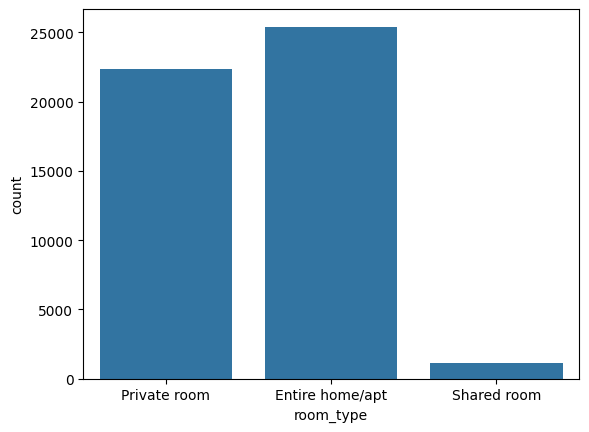

In [8]:
sns.countplot(x='room_type',data=df)

The classes are imbalanced -> shared room is a small minority.

**Distribution of numeric columns**

In [9]:
df.select_dtypes(include='number').columns

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [10]:
numeric_cols=['price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

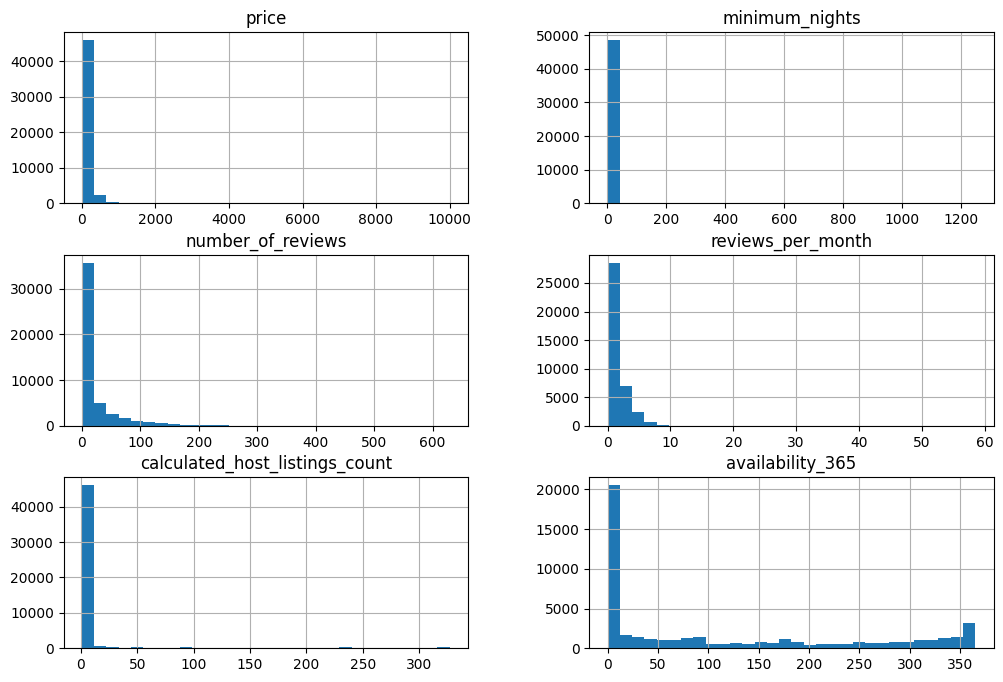

In [11]:
df[numeric_cols].hist(bins=30,figsize=(12,8))

#**Univariate Analysis- Categorical Features**

In [12]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<Axes: xlabel='neighbourhood_group', ylabel='count'>

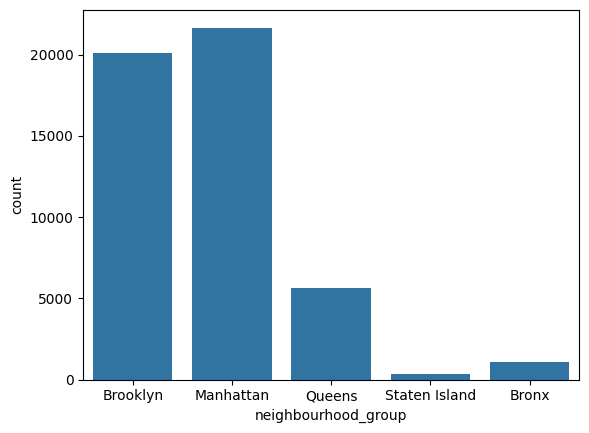

In [13]:
sns.countplot(data=df,x='neighbourhood_group')

#**Bivariate Analysis-  Features vs Target**

<Axes: xlabel='room_type', ylabel='price'>

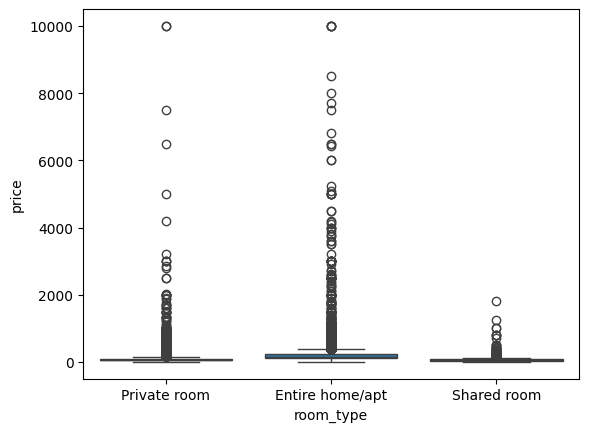

In [14]:
sns.boxplot(x='room_type',y='price',data=df)

**Correlation Between Numeric Features**

In [15]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [16]:
corr=df[numeric_cols+ ['latitude','longitude']].corr()

<Axes: >

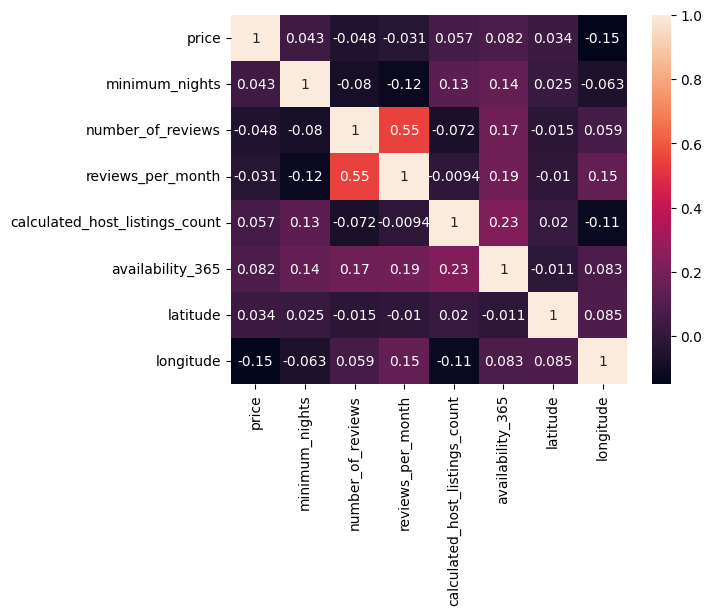

In [17]:
sns.heatmap(corr,annot=True)

**Geographical Distribution (Bonus Visual)**

<Axes: xlabel='latitude', ylabel='longitude'>

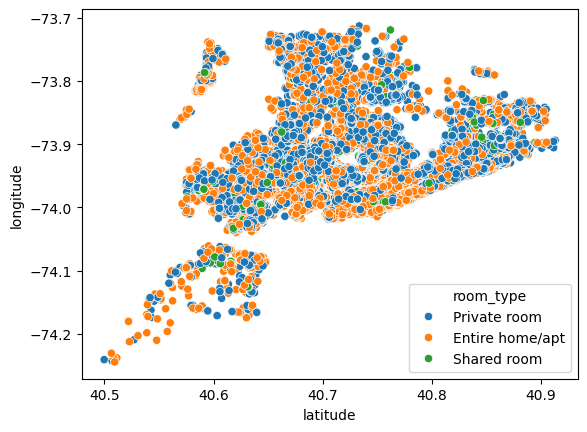

In [18]:
sns.scatterplot(x='latitude',y='longitude',data=df,hue='room_type')

#**Data Cleaning & Feature Engineering**

In [19]:
df_clean=df.drop(columns=['id','name','host_id'	,'host_name','last_review'])

In [20]:
df_clean.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0


In [21]:
df_clean[numeric_cols].skew()

,0
price,19.118939
minimum_nights,21.827275
number_of_reviews,3.690635
reviews_per_month,3.130189
calculated_host_listings_count,7.933174
availability_365,0.763408


In [22]:
df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)

In [23]:
df_clean.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [24]:
# cap extreme outliers instead of deleting rows

price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df_clean['minimum_nights'].clip(upper=nights_cap)

In [25]:
X=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

#**Train / Test Split**

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

#**Preprocessing : ColumnTransformer + Pipeline**

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer

In [28]:
numeric_cols=['latitude','longitude','price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

categorical_cols=['neighbourhood','neighbourhood_group']

#1 Pipeline -> for numeric columns

numeric_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])


#Pipeline -< for Categorical columns
categorical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])


preprocessor=ColumnTransformer(transformers=[
 ('numerical',numeric_pipeline,numeric_cols),
 ('categorical',categorical_pipeline,categorical_cols)
 ])

In [29]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood', 'neighbourhood_group'])])

In [30]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

#**Trying Multiple Algorithm**

**SMOTE-> synthetic minority oversampling for class Imbalance**

-------------------------------

1. High Chance of data Leakage
2. Overfitting issue

#**We Creating some model like**

-------------------------------

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [32]:
from sklearn.model_selection import cross_validate

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring={
            'accuracy': 'accuracy',
            'f1_macro': 'f1_macro'
        }
    )

    print(f"{name}")
    print(f"Accuracy : {scores['test_accuracy'].mean():.4f}")
    print(f"Macro F1 : {scores['test_f1_macro'].mean():.4f}")
    print("-" * 40)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression
Accuracy : 0.6620
Macro F1 : 0.5254
----------------------------------------
Decision Tree
Accuracy : 0.7876
Macro F1 : 0.6588
----------------------------------------
Random Forest
Accuracy : 0.8541
Macro F1 : 0.7255
----------------------------------------
Gradient Boosting
Accuracy : 0.8505
Macro F1 : 0.7051
----------------------------------------


In [33]:
from sklearn.model_selection import RandomizedSearchCV

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[

    ('Preprocessor', preprocessor),

    ('Classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))

])

param_distribution = {

    'Classifier__n_estimators': [100, 200, 150, 300],

    'Classifier__max_depth': [8, 12, 15, 20, None],

    'Classifier__min_samples_split': [2, 5, 10]

}

random_search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('categ...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood',
                                                                                'neighbourhood_group'])])),
                                             ('Classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'Classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'Classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'Classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [35]:
print('Best Parameters',random_search.best_params_)
print('Best cv macro-f1',random_search.best_score_)

#RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       #n_estimators=200, random_state=42)

Best Parameters {'Classifier__n_estimators': 200, 'Classifier__min_samples_split': 10, 'Classifier__max_depth': None}
Best cv macro-f1 0.7382489436356288


#**Metrices**

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = random_search.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8569383372532979

Classification Report:
                  precision    recall  f1-score   support

Entire home/apt       0.87      0.88      0.88      5082
   Private room       0.84      0.86      0.85      4465
    Shared room       0.84      0.39      0.53       232

       accuracy                           0.86      9779
      macro avg       0.85      0.71      0.75      9779
   weighted avg       0.86      0.86      0.85      9779


Confusion Matrix:
 [[4457  625    0]
 [ 615 3833   17]
 [  22  120   90]]


In [40]:
import joblib

# Best model/pipeline
best_model = random_search.best_estimator_

# Save model
joblib.dump(best_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [43]:
X_train

,neighbourhood_group,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
12776,Brooklyn,Williamsburg,40.71602,-73.96248,130,2,67,1.57,3,252
38717,Manhattan,Tribeca,40.71519,-74.00654,312,30,0,0.00,232,38
35008,Manhattan,West Village,40.73202,-74.00348,150,2,2,0.21,3,56
266,Brooklyn,Williamsburg,40.70690,-73.95467,60,17,14,0.14,4,362
38787,Brooklyn,Bedford-Stuyvesant,40.69054,-73.92801,75,7,4,0.64,1,10
...,...,...,...,...,...,...,...,...,...,...
47847,Manhattan,Harlem,40.81524,-73.94168,47,1,0,0.00,2,115
31273,Brooklyn,Gowanus,40.66889,-73.99115,95,1,3,0.22,1,221
36321,Brooklyn,Fort Greene,40.68832,-73.97731,175,3,38,4.15,1,122
5928,Manhattan,Morningside Heights,40.80801,-73.95820,132,2,9,0.16,1,0


In [44]:
y_train

,room_type
12776,Entire home/apt
38717,Entire home/apt
35008,Private room
266,Private room
38787,Entire home/apt
...,...
47847,Private room
31273,Private room
36321,Entire home/apt
5928,Entire home/apt


In [45]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
